# Probability Distributions

## Introduction
In quantitative finance and stochastic calculus, probability distributions serve as the fundamental building blocks for modeling asset returns, interest rates, and credit events. 

This module catalogs the principal probability distributions, strictly divided into **Continuous** and **Discrete** categories. For each distribution, we mathematically formulate the Density/Mass function, the **Cumulative Distribution Function (CDF)**, and the **Quantile Function (Inverse CDF)**. The code simulates these elements stochastically and plots both the empirical distribution and the CDF.

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Set plotting style for academic presentation
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Part I: Continuous Distributions

## 1. The Normal (Gaussian) Distribution
Underpinning the geometric Brownian motion model in the Black-Scholes-Merton framework.

Let $X \sim \mathcal{N}(\mu, \sigma^2)$.

**Probability Density Function (PDF):**
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right)$$

**Cumulative Distribution Function (CDF):**
$$F(x) = P(X \le x) = \Phi\left(\frac{x-\mu}{\sigma}\right)$$
where $\Phi$ is the standard normal CDF.

**Quantile Function (Percent Point Function):**
$$Q(p) = \inf\{x \in \mathbb{R} : p \le F(x)\} = \mu + \sigma \Phi^{-1}(p)$$

* **Mean:** $\mathbb{E}[X] = \mu$
* **Variance:** $\text{Var}(X) = \sigma^2$

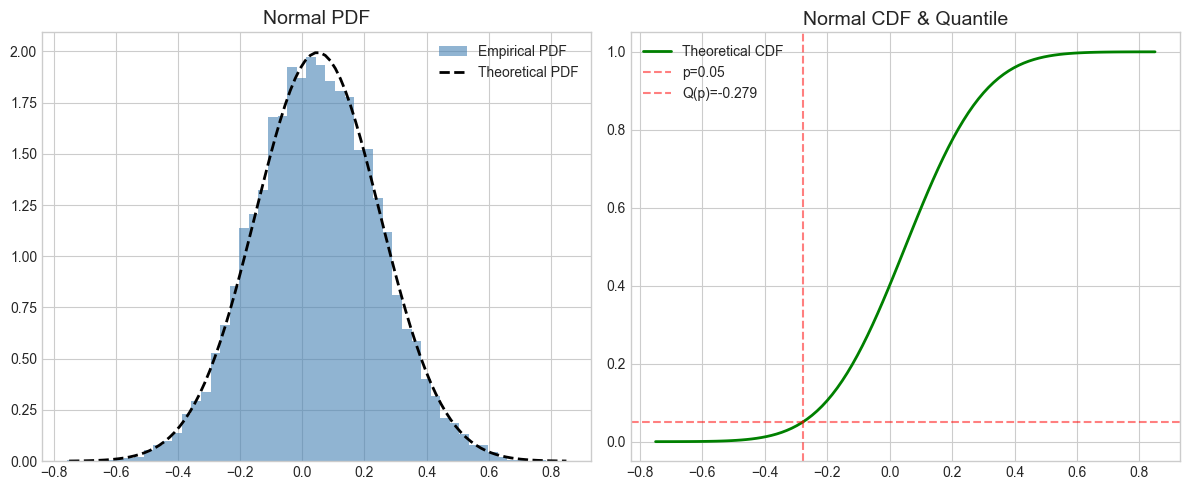

In [ ]:
# Normal distribution
mu = 0.05
sigma = 0.20
num_samples = 10000

samples = np.random.normal(mu, sigma, num_samples)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
pdf = stats.norm.pdf(x, mu, sigma)
cdf = stats.norm.cdf(x, mu, sigma)

p = 0.05
q_05 = stats.norm.ppf(p, mu, sigma)

fig, ax = plt.subplots(1, 2)

ax[0].hist(samples, bins=50, density=True, alpha=0.6, color='steelblue', label='Empirical PDF')
ax[0].plot(x, pdf, 'k--', linewidth=2, label='Theoretical PDF')
ax[0].set_title('Normal PDF')
ax[0].legend()

ax[1].plot(x, cdf, 'g-', linewidth=2, label='Theoretical CDF')
ax[1].axhline(p, color='r', linestyle='--', alpha=0.5, label=f'p={p}')
ax[1].axvline(q_05, color='r', linestyle='--', alpha=0.5, label=f'Q(p)={q_05:.3f}')
ax[1].set_title('Normal CDF & Quantile')
ax[1].legend()

plt.tight_layout()
plt.show()

## 2. The Lognormal Distribution
Models strictly positive asset prices $S_t$.

Let $Y \sim \text{Lognormal}(\mu, \sigma^2)$.

**PDF:**
$$f(y) = \frac{1}{y \sigma \sqrt{2\pi}} \exp\left(-\frac{(\ln y - \mu)^2}{2\sigma^2}\right), \quad y > 0$$

**CDF:**
$$F(y) = \Phi\left(\frac{\ln y - \mu}{\sigma}\right)$$

**Quantile Function:**
$$Q(p) = \exp\left(\mu + \sigma \Phi^{-1}(p)\right)$$

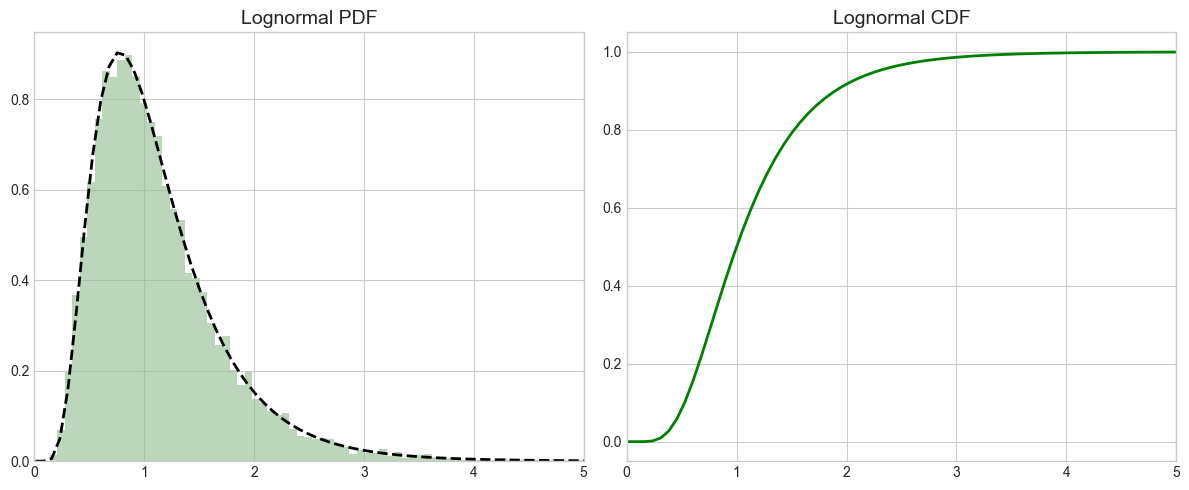

In [ ]:
# Log-normal distribution

mu_log = 0.0
sigma_log = 0.5

samples = np.random.lognormal(mu_log, sigma_log, num_samples)
x = np.linspace(0.01, np.exp(mu_log + 4*sigma_log), 100)

pdf = stats.lognorm.pdf(x, s=sigma_log, scale=np.exp(mu_log))
cdf = stats.lognorm.cdf(x, s=sigma_log, scale=np.exp(mu_log))

fig, ax = plt.subplots(1, 2)
ax[0].hist(samples, bins=100, density=True, alpha=0.6, color='darkseagreen')
ax[0].plot(x, pdf, 'k--', linewidth=2)
ax[0].set_title('Lognormal PDF')
ax[0].set_xlim(0, 5)

ax[1].plot(x, cdf, 'g-', linewidth=2)
ax[1].set_title('Lognormal CDF')
ax[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

## 3. Student's t-Distribution
Accounts for 'fat tails' in empirical returns.

Let $X \sim t(\nu)$.

**PDF:**
$$f(x) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\Gamma\left(\frac{\nu}{2}\right)} \left(1+\frac{x^2}{\nu} \right)^{-\frac{\nu+1}{2}}$$

**CDF:** Expressed via the regularized incomplete beta function.

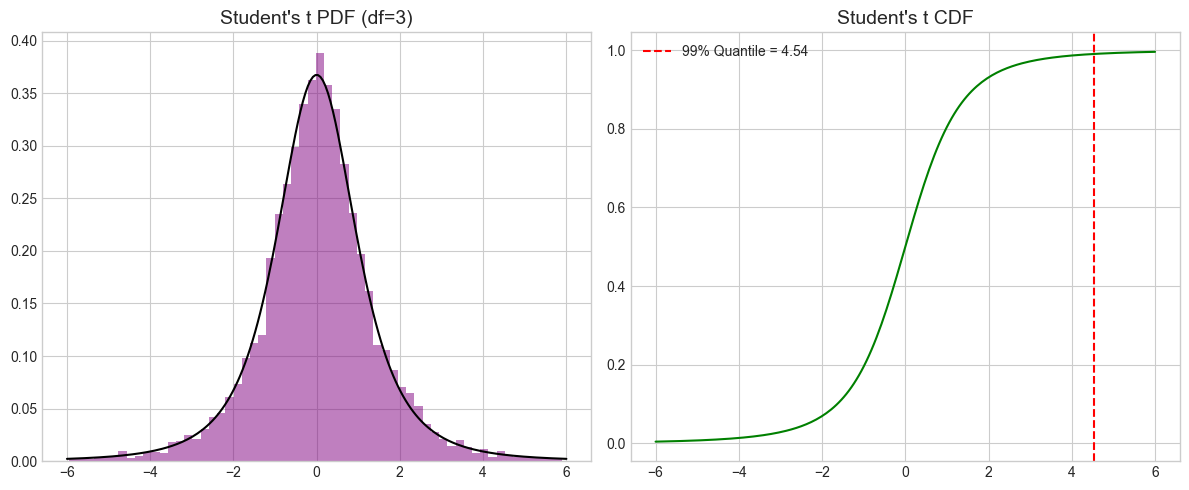

In [ ]:
# t-Student Distribution
df = 3
samples = np.random.standard_t(df, size=num_samples)
x = np.linspace(-6, 6, 200)

pdf = stats.t.pdf(x, df)
cdf = stats.t.cdf(x, df)
q_99 = stats.t.ppf(0.99, df)

samples_filtered = samples[(samples > -6) & (samples < 6)]

fig, ax = plt.subplots(1, 2)
ax[0].hist(samples_filtered, bins=60, density=True, alpha=0.5, color='purple')
ax[0].plot(x, pdf, 'k-')
ax[0].set_title(f"Student's t PDF (df={df})")

ax[1].plot(x, cdf, 'g-')
ax[1].axvline(q_99, color='r', linestyle='--', label=f'99% Quantile = {q_99:.2f}')
ax[1].set_title("Student's t CDF")
ax[1].legend()
plt.tight_layout()
plt.show()

## 4. The Exponential Distribution
Models time to default (hazard rates) with a memoryless property.

Let $T \sim \text{Exponential}(\lambda)$.

**PDF:**
$$f(t) = \lambda e^{-\lambda t}, \quad t \ge 0$$

**CDF:**
$$F(t) = P(T \le t) = 1 - e^{-\lambda t}$$

**Quantile Function:**
$$Q(p) = -\frac{\ln(1-p)}{\lambda}$$

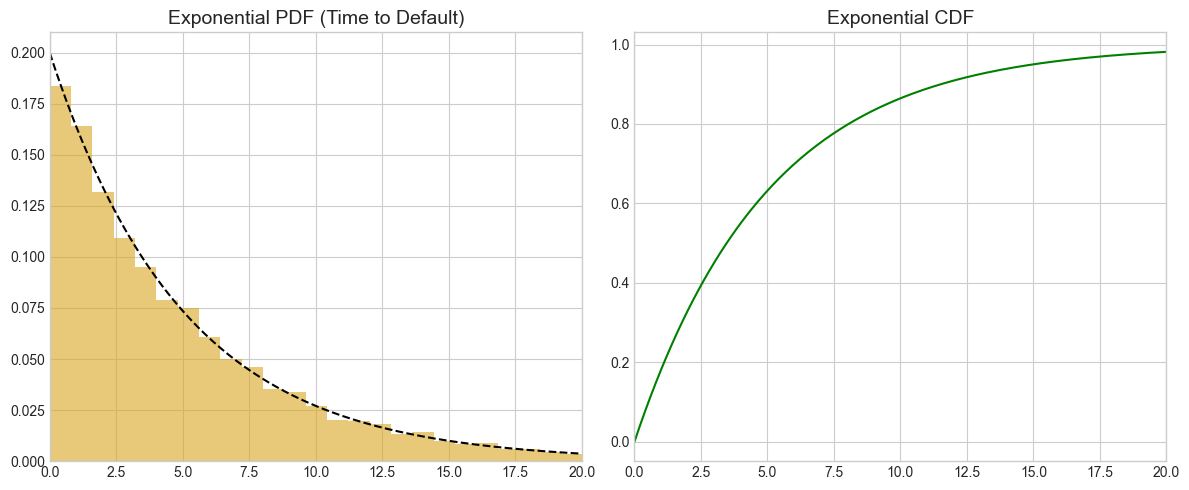

In [ ]:
# Exponential distribution

lam = 0.2
beta = 1.0 / lam
samples = np.random.exponential(beta, num_samples)
t = np.linspace(0, beta * 4, 200)

pdf = stats.expon.pdf(t, scale=beta)
cdf = stats.expon.cdf(t, scale=beta)

fig, ax = plt.subplots(1, 2)
ax[0].hist(samples, bins=60, density=True, alpha=0.6, color='goldenrod')
ax[0].plot(t, pdf, 'k--')
ax[0].set_title('Exponential PDF (Time to Default)')
ax[0].set_xlim(0, beta*4)

ax[1].plot(t, cdf, 'g-')
ax[1].set_title('Exponential CDF')
ax[1].set_xlim(0, beta*4)
plt.tight_layout()
plt.show()

# Part II: Discrete Distributions

## 5. The Bernoulli Distribution
Models a single default event. Outcomes $x \in \{0, 1\}$.

Let $X \sim \text{Bernoulli}(p)$.

**Probability Mass Function (PMF):**
$$P(X=x) = p^x (1-p)^{1-x}$$

**CDF:**
$$F(x) = \begin{cases} 0 & x < 0 \\ 1-p & 0 \le x < 1 \\ 1 & x \ge 1 \end{cases}$$

**Quantile Function:** Step function crossing thresholds at $1-p$.

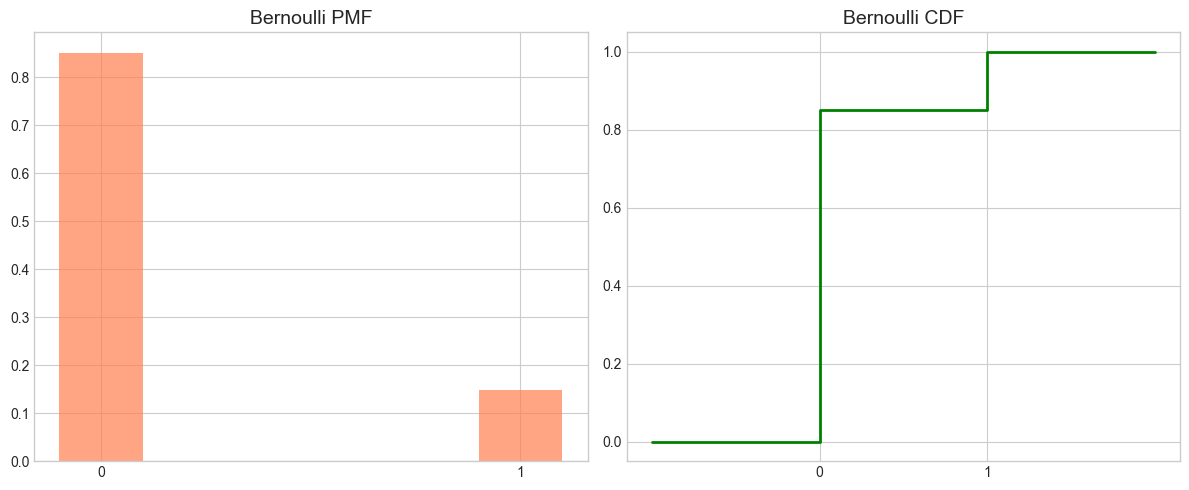

In [ ]:
# Bernulli distribution

p = 0.15
samples = np.random.binomial(1, p, num_samples)
x = np.array([0, 1])
pmf = [1 - p, p]

# CDF points for step plot
x_step = [-1, 0, 1, 2]
cdf_step = [0, 1-p, 1, 1]

fig, ax = plt.subplots(1, 2)
unique, counts = np.unique(samples, return_counts=True)
ax[0].bar(x, counts/num_samples, width=0.2, color='coral', alpha=0.7)
ax[0].set_title('Bernoulli PMF')
ax[0].set_xticks([0, 1])

ax[1].step(x_step, cdf_step, where='post', color='g', linewidth=2)
ax[1].set_title('Bernoulli CDF')
ax[1].set_xticks([0, 1])
plt.tight_layout()
plt.show()

## 6. The Binomial Distribution
The mathematical engine behind the Binomial Option Pricing Model (BOPM).

Let $X \sim \text{Binomial}(n, p)$.

**PMF:**
$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$

**CDF:**
$$F(k) = \sum_{i=0}^{\lfloor k \rfloor} \binom{n}{i} p^i (1-p)^{n-i}$$

**Quantile Function:** Gives the smallest integer $k$ such that $F(k) \ge p$.

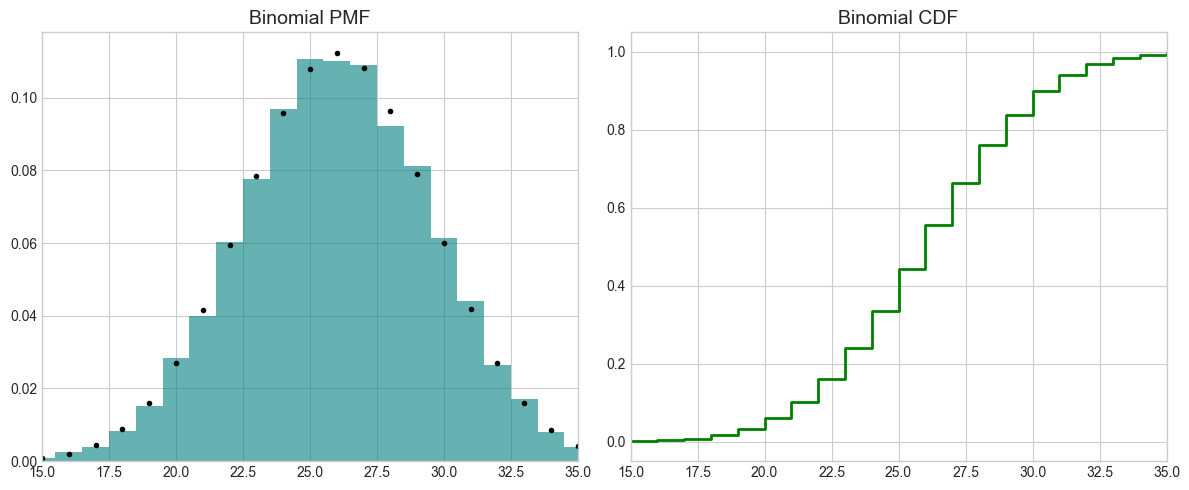

In [ ]:
# Binomial distribution

n_trials = 50
p_up = 0.52
samples = np.random.binomial(n_trials, p_up, num_samples)
k = np.arange(0, n_trials + 1)

pmf = stats.binom.pmf(k, n_trials, p_up)
cdf = stats.binom.cdf(k, n_trials, p_up)

fig, ax = plt.subplots(1, 2)
ax[0].hist(samples, bins=np.arange(-0.5, n_trials+1.5, 1), density=True, alpha=0.6, color='teal')
ax[0].plot(k, pmf, 'ko', markersize=3)
ax[0].set_xlim(15, 35)
ax[0].set_title('Binomial PMF')

ax[1].step(k, cdf, where='post', color='g', linewidth=2)
ax[1].set_xlim(15, 35)
ax[1].set_title('Binomial CDF')
plt.tight_layout()
plt.show()

## 7. The Poisson Distribution
Models discrete events over time, such as defaults in intensity-based models.

Let $N \sim \text{Poisson}(\lambda)$.

**PMF:**
$$P(N=k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

**CDF:**
$$F(k) = e^{-\lambda} \sum_{i=0}^{\lfloor k \rfloor} \frac{\lambda^i}{i!}$$

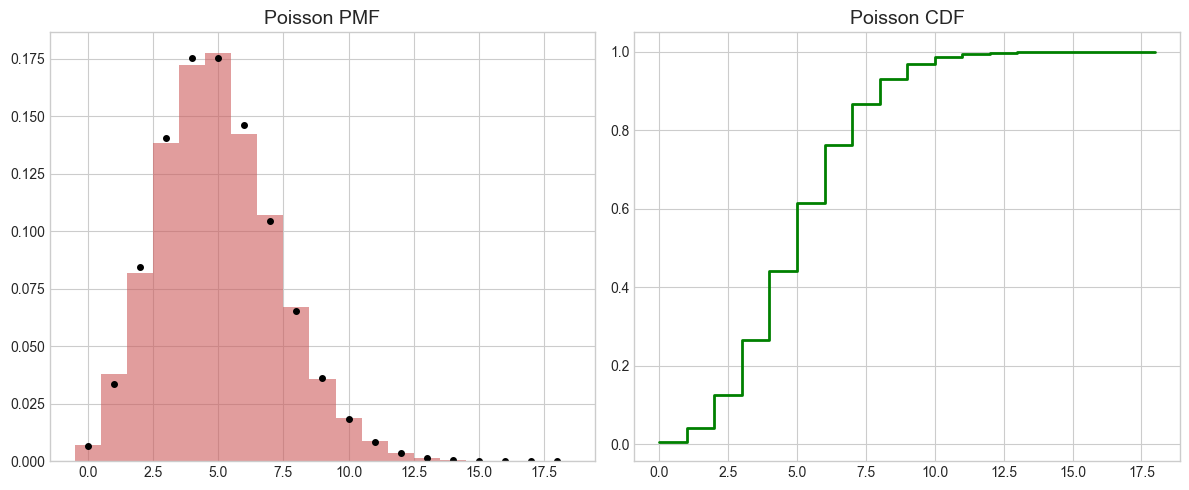

In [ ]:
# Poisson distribution

lam = 5
samples = np.random.poisson(lam, num_samples)
k = np.arange(0, np.max(samples) + 1)

pmf = stats.poisson.pmf(k, lam)
cdf = stats.poisson.cdf(k, lam)

fig, ax = plt.subplots(1, 2)
ax[0].hist(samples, bins=np.arange(-0.5, np.max(samples)+1.5, 1), density=True, alpha=0.6, color='indianred')
ax[0].plot(k, pmf, 'ko', markersize=4)
ax[0].set_title('Poisson PMF')

ax[1].step(k, cdf, where='post', color='g', linewidth=2)
ax[1].set_title('Poisson CDF')
plt.tight_layout()
plt.show()